# Symbolic algebra: sympy for physics

## 1. Lennard-Jones Potential and Forces (optimisation)
The potential energy of a particle in a field has the form:

$$V(r) = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right]$$

where $r$ is the distance between the particles, $\epsilon$ is the depth of the potential well describing the strength of the attraction, and $\sigma$ is the distance at which the potential energy is zero.

It describes attractive and repulsive forces, that depends of the distance. Appears when studying interaction between molecules.

### (a) Create a python function to compute this potential $V(r)$ as a function of $r$ for fiducial values of $\epsilon$ and $\sigma$. Then, create an appropriate vector for $r$ and plot this potential $V(r)$ versus $r$.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [2]:
def len_jon_pot(r, eps, sig):
    """
    This function computes the Lennard-Jones potential between any two particles.
    Inputs:
    r -> vector, radial coordinate.
    eps -> float, depth of the potential well.
    sig -> float, distance at which the potential is zero.
    Outputs:
    V -> vector of Lennard-Jones potential values
    """
    # Define the Lennard-Jones potential formula
    V = 4 * eps * ((sig / r)**12 - (sig / r)**6)
    return V

In [3]:
# Define parameters for the Lennard-Jones potential
eps_1 = 2.0
sig_1 = 1.0

# Generate an appropriate range of r values
r = np.linspace(1.e-4, 4*sig_1, 1000)

# Calculate the Lennard-Jones potential
V = len_jon_pot(r, eps_1, sig_1)

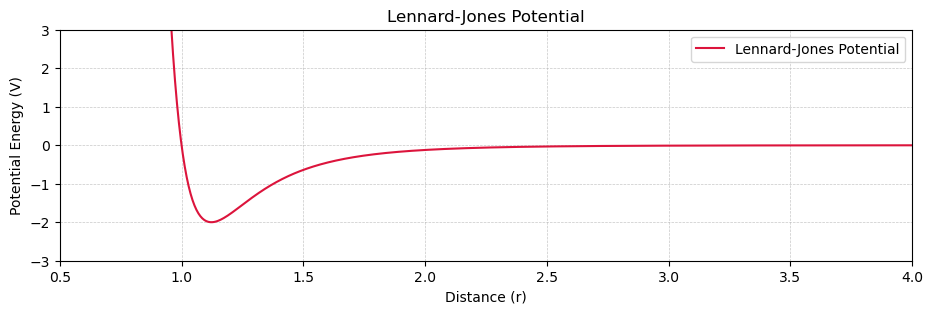

In [4]:
# Plotting

plt.figure(figsize = (11, 3))
plt.plot(r, V, label='Lennard-Jones Potential', color='crimson')
plt.title('Lennard-Jones Potential')
plt.xlabel('Distance (r)')
plt.ylabel('Potential Energy (V)')

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.ylim(-1.5*eps_1, 1.5*eps_1) #it's essential to limit the y-axis
plt.xlim(0.5, 4.*sig_1)
plt.legend()
plt.show()

### (b) Use sympy to compute the force: $F(r)=-\frac{dV}{dr}$ experienced by a particle at a distance $r$. Then, lambdify your expression and plot the $F(r)$ versus $r$.

In [5]:
# Define the function and symbols for symbolic computation
r1 = sp.Symbol('r1', positive=True) #r was a vector
V1 = len_jon_pot(r1, eps_1, sig_1)
print(type(V1)) #it becomes a sympy expression

# Compute the force
f_r = -sp.diff(V1, r1)

#print(f_r)
display("The force is:", f_r)

<class 'sympy.core.add.Add'>


'The force is:'

-48.0/r1**7 + 96.0/r1**13

In [6]:
# Let's lambdify the force function for numerical evaluation
f_r1 = sp.lambdify(r1, f_r, "numpy")

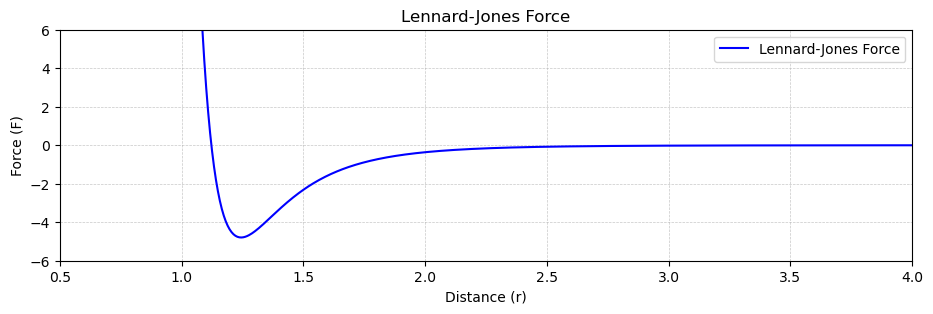

In [7]:
# Plotting

plt.figure(figsize = (11, 3))
plt.plot(r, f_r1(r), label = 'Lennard-Jones Force', color = 'blue')
plt.title('Lennard-Jones Force')
plt.xlabel('Distance (r)')
plt.ylabel('Force (F)')

plt.grid(True, linestyle = '--', linewidth = 0.5, alpha = 0.7)
plt.ylim(-3.*eps_1, 3.*eps_1) #it's essential to limit the y-axis
plt.xlim(0.5, 4.*sig_1)
plt.legend()
plt.show()

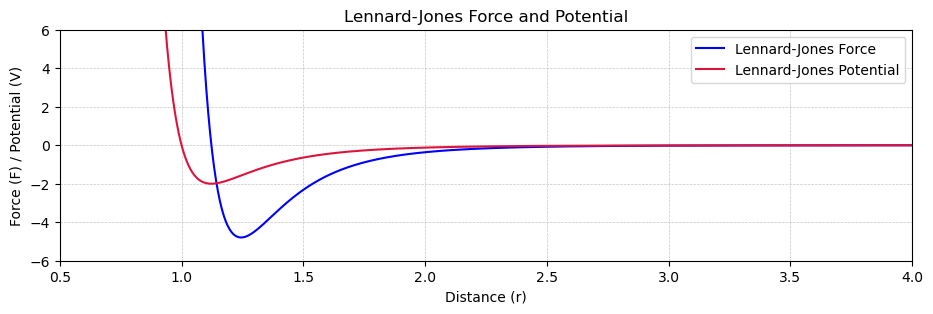

In [8]:
# Comparison
# Plotting
plt.figure(figsize = (11, 3))
plt.plot(r, f_r1(r), label = 'Lennard-Jones Force', color = 'blue')
plt.plot(r, V, label = 'Lennard-Jones Potential', color = 'crimson')
plt.title('Lennard-Jones Force and Potential')
plt.xlabel('Distance (r)')
plt.ylabel('Force (F) / Potential (V)')

plt.grid(True, linestyle = '--', linewidth = 0.5, alpha = 0.7)
plt.ylim(-3.*eps_1, 3.*eps_1) #it's essential to limit the y-axis
plt.xlim(0.5, 4.*sig_1)
plt.legend()
plt.show()

### (c) Find the maximum possible value of the attractive force, $F_{max}$, and the distance, $r_{max}$, at which the particle would be subjected to this force.

We wish to find the distance $r$ at which $\frac{d F(r)}{dr} = 0$.

In [9]:
# We use sympy to solve the ODE

# Define the equation
eq_max = sp.Eq(sp.diff(f_r, r1),0)

display(eq_max)

# Solve the ODE
r_max = sp.solve(eq_max)

display(r_max)

Eq(336.0/r1**8 - 1248.0/r1**14, 0)

[1.24445506025981]

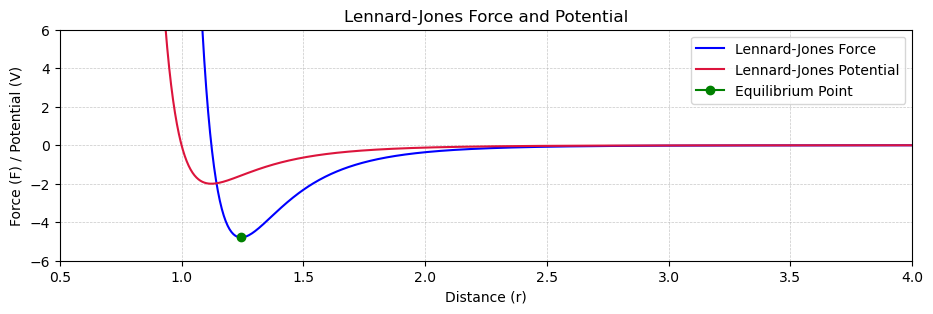

In [10]:
# Comparison
# Plotting
plt.figure(figsize = (11, 3))
plt.plot(r, f_r1(r), label = 'Lennard-Jones Force', color = 'blue')
plt.plot(r, V, label = 'Lennard-Jones Potential', color = 'crimson')
plt.plot(r_max[0], f_r1(r_max[0]), marker = 'o', label='Equilibrium Point', color = "green")
plt.title('Lennard-Jones Force and Potential')
plt.xlabel('Distance (r)')
plt.ylabel('Force (F) / Potential (V)')

plt.grid(True, linestyle = '--', linewidth = 0.5, alpha = 0.7)
plt.ylim(-3.*eps_1, 3.*eps_1) #it's essential to limit the y-axis
plt.xlim(0.5, 4.*sig_1)
plt.legend()
plt.show()

### VTK Output:
We want to save: r, V in a VTK-like file.

In [11]:
# VTK formatting

from pyevtk.hl import gridToVTK, pointsToVTK

In [12]:
y = np.array([0.])
z = np.array([0.])

gridToVTK("./v_potential2", r, y, z, cellData={"vr": V, "ra": r})

'/home/prostofsound/jnotebooks/computational-physics-1/Notes/Unit-5/v_potential2.vtr'

### (d) Describe the behavior of the potential at short and long distances. At which "equilibrium" distance, $r_0$, does the force become zero?

At short distances it is repulsive and at long distances it's attractive.

The force becomes zero when we're at the minimum value of the potential.

### (e) Discuss the physical significance of the Lennard-Jones potential in real-world systems (e.g. the meaning of $\sigma$ and $\epsilon$).  Provide 2 examples of systems where this potential is applicable.

$\epsilon$ could be related to a proportionality constant between quantities, under certain conditions. On the other hand, $\sigma$ may indicate the limit where there is no useful relation between the quantities.

## 2. Population dynamics (solutions to ODEs)

The **Verhulst-Pearl model** is used to study animal population dynamics. This model is also called **logistic growth model** and assumes that $P(t)$ satisfies the following ODE:


$$\frac{dP}{dt}=\alpha\,P\left(1-\frac{P}{\beta}\right)$$


where $\alpha$ is the growth rate and $\beta$ is the limiting size for the population (also called the environment carrying capacity).

### (a) Use sympy to find the general analytical solution to this ODE.

In [13]:
# Define the function
p = sp.Function('P', real=True)

# Define the symbols
a, b, t = sp.symbols('a b t', real=True) #a: alpha, b: beta, t: time

# Define the differential equation
diffeq = sp.Eq(p(t).diff(t) - a*p(t)*(1 - p(t)/b), 0)

display(diffeq)

Eq(-a*(1 - P(t)/b)*P(t) + Derivative(P(t), t), 0)

In [14]:
# Find the solution
p_sln = sp.dsolve(diffeq, p(t))

display(p_sln)

Eq(P(t), b*exp(C1*b + a*t)/(exp(C1*b + a*t) - 1))

### (b) Imagine we use this equation to study the population dynamics of a bird species re-introduced into nature, knowing that the test environment can only host $20$ individuals. We liberate $10$ individuals of this species in the wild, and we know that the growth rate is $0.2$ individuals per month. Rewrite and recompute both the ODE and its solution for this set of conditions.

In [15]:
# Fix the parameters
# Growth rate
a = 0.2
# Carrying capacity
b = 20

# ODE
# Define the differential equation
ode_v = sp.Eq(p(t).diff(t) - a*p(t)*(1 - p(t)/b), 0)

display(ode_v)

Eq(-0.2*(1 - P(t)/20)*P(t) + Derivative(P(t), t), 0)

In [16]:
# Find the solution
p_sln_v = sp.dsolve(ode_v, p(t), ics={p(0): 10}) #add the population at time t=0

display(sp.simplify(p_sln_v))

Eq(P(t), 20.0*exp(0.2*t)/(exp(0.2*t) + 1))

### (c) Lambify your expression, make a plot of the analytical solution and label it appropriately.

In [17]:
# Lambdify the expression
p_np = sp.lambdify(t, p_sln_v.rhs, 'numpy')

# Generate time values
t_axis = np.arange(0, 60, 0.0001)

# Evaluate the solution
p_eval = p_np(t_axis)

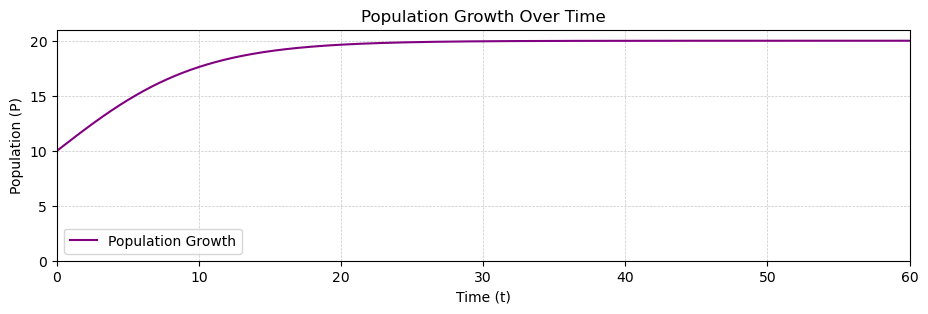

In [18]:
#Plotting
plt.figure(figsize=(11, 3))
plt.plot(t_axis, p_eval, label='Population Growth', color='purple')
plt.title('Population Growth Over Time')
plt.xlabel('Time (t)')
plt.xlim(0, 60)
plt.ylim(0, 21) # Limit the y-axis to focus on the population growth
plt.ylabel('Population (P)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend()
plt.show()

### (d) Briefly comment on the behavior of the population size over time, and the eventual population size as $t \to \infty$. What are the biological interpretations of the parameters $\alpha$ and $\beta$ ?

$\alpha$ could be the birth rate and $\beta$ the environment limitations.

### (e) Why does the population growth slow down as $P(t)$ approaches $\beta$ ? How might the model change if external factors (e.g., predators, diseases, or resource scarcity) are introduced?

Because $\beta$ is the saturation number of the population, the environment does not allow it, maybe due to the population being part of an experiment (controlled food and birth rate).

When introduce predators we need to include an ODE describing the prey-predator interaction.